# Chargement des dataset Input_Space et Output_Space

In [1]:
import numpy as np
import pandas as pd
Input_Space=pd.read_csv('Input_Space.csv', sep=" ",header=None)
Input_Space.columns = [ "RM_1", "RM_2" ,"RM_3", "RM_4","BLOC_1", "BLOC_2" ,"PR_temp" ,"PR_speed"]
Input_Space=Input_Space.iloc[1:]
Input_Space=Input_Space.applymap(lambda x: str(x.replace(',','.')))
Input_Space

,RM_1,RM_2,RM_3,RM_4,BLOC_1,BLOC_2,PR_temp,PR_speed
1,0.5,4,3.5,10,18,28,23,50
2,1,0.5,5,15,18,28,18,40
3,1.5,1,2,7,18,28,25,70
4,2,1.5,3.5,10,18,28,30,25
5,3.5,2,0.5,9,18,28,23,80
6,0.5,0.5,1,12,18,28,27,90
7,1,1,1.5,10,18,28,18,50
8,1.5,1.5,2,13,18,28,32,40
9,2,2,5,14,18,28,30,70
10,3.5,3.5,4,7,18,28,23,25


In [2]:
Output_Space=pd.read_csv('Output_Space.csv', sep=" ",header=None)
Output_Space.columns =["Cost","Visco" ,"Ph","Rheo","Stability", "Texture" ,"Senso1" ,"Naturality","Microbio30days"]
Output_Space=Output_Space.iloc[1:]
Output_Space=Output_Space.applymap(lambda x: str(x.replace(',','.')))
Output_Space

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
1,128,25000,6.920818754,67.48066245,1,2,2,100,649.5
2,137.5,27625,11.79250028,16.582639,1,1,3,25,546
3,55,39250,4.110698297,54.85932518,1,2,3,75,1009
4,120.5,48875,6.890252762,99.77061992,0,3,3,92.5,23.5
5,72,56500,6.259637311,13.4201443,0,1,5,85,1245.5
6,9.5,31625,9.440691989,70.87771297,1,3,2,35,1377
7,37,27250,6.5,64.22346928,0,2,3,47.5,737.5
8,74.5,45875,10.10374944,50.86535772,1,2,3,75,289
9,178,48500,10.75696195,89.46856227,1,3,4,95,929
10,188.5,55375,3.785818691,98.78171887,0,3,4,100,147


# Application de la normalisation avec “MinMaxScaler” dans le package #preprocessing.

In [3]:
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# MIN MAX SCALING
minmax_scale = MinMaxScaler().fit(Output_Space[['Cost', 'Visco','Ph', 'Rheo','Stability', 'Texture','Senso1', 'Naturality','Microbio30days']])
df_minmax = minmax_scale.transform(Output_Space[['Cost', 'Visco','Ph', 'Rheo','Stability', 'Texture','Senso1', 'Naturality','Microbio30days']])
df_minmax=pd.DataFrame(df_minmax)
df_minmax.columns =["Cost","Visco" ,"Ph","Rheo","Stability", "Texture" ,"Senso1" ,"Naturality","Microbio30days"]
df_minmax

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,0.662011,0.000000,0.433882,0.626059,1.0,0.5,0.000000,1.000000,0.413338
1,0.715084,0.050481,1.000000,0.036624,1.0,0.0,0.333333,0.166667,0.344998
2,0.254190,0.274038,0.107329,0.479895,1.0,0.5,0.333333,0.722222,0.650710
3,0.620112,0.459135,0.430330,1.000000,0.0,1.0,0.333333,0.916667,0.000000
4,0.349162,0.605769,0.357049,0.000000,0.0,0.0,1.000000,0.833333,0.806867
5,0.000000,0.127404,0.726706,0.665400,1.0,1.0,0.000000,0.277778,0.893694
6,0.153631,0.043269,0.384980,0.588339,0.0,0.5,0.333333,0.416667,0.471443
7,0.363128,0.401442,0.803757,0.433642,1.0,0.5,0.333333,0.722222,0.175305
8,0.941341,0.451923,0.879664,0.880695,1.0,1.0,0.666667,0.944444,0.597887
9,1.000000,0.584135,0.069576,0.988548,0.0,1.0,0.666667,1.000000,0.081545


# Random Forest model and SHAP for Cost prediction 

In [4]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y1 = Output_Space.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y1) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values1 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y1_100 = 100*Output_Space.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y1_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y1_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y1_001 =0.01* Output_Space.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y1_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y1_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y1 =df_minmax.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y1, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y1) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values_minmax = shap.TreeExplainer(model).shap_values(X)


#  Analyse Visuelle 

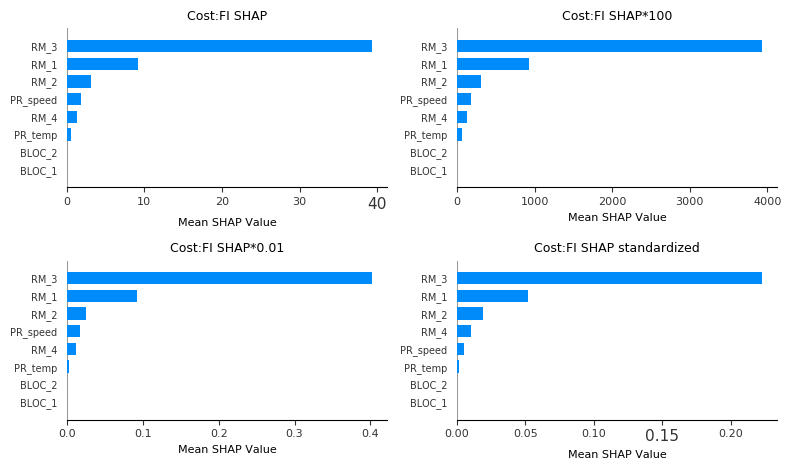

In [26]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Cost:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values1, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Cost:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Cost:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Cost:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

# Random Forest model and SHAP for Visco prediction 

In [6]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y2 = Output_Space.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y2) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values2 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y2_100 = 100*Output_Space.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y2_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y2_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values2_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y2_001 =0.01* Output_Space.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y2_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y2_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values2_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y2 =df_minmax.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y2) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values2_minmax = shap.TreeExplainer(model).shap_values(X)


#   Analyse Visuelle 

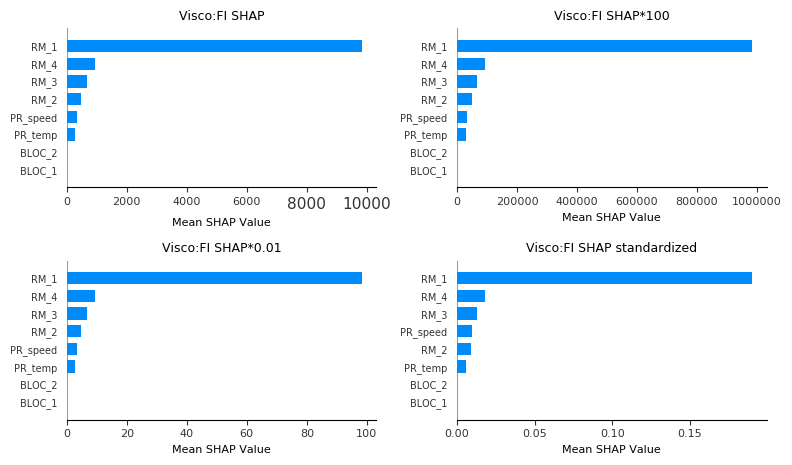

In [25]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Visco:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values2, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Visco:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values2_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Visco:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values2_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Visco:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values2_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

#  Random Forest model and SHAP  for Ph prediction

In [8]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y3 = Output_Space.loc[:,'Ph'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y3) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values3 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y3_100 = 100*Output_Space.loc[:,'Ph'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y3_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y3_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values3_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y3_001 =0.01* Output_Space.loc[:,'Ph'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y3_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y3_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values3_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y3 =df_minmax.loc[:,'Ph'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y3) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values3_minmax = shap.TreeExplainer(model).shap_values(X)


#   Analyse Visuelle 

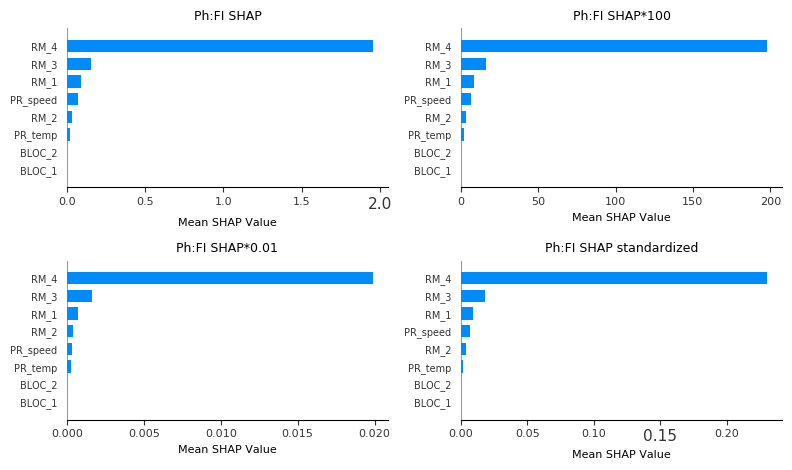

In [24]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Ph:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values3, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Ph:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values3_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Ph:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values3_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Ph:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values3_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

# Random Forest model and SHAP for Rheo prediction 

In [10]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y4 = Output_Space.loc[:,'Rheo'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y4) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values4 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y4_100 = 100*Output_Space.loc[:,'Rheo'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y4_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y4_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values4_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y4_001 =0.01* Output_Space.loc[:,'Rheo'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y4_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y4_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values4_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y4=df_minmax.loc[:,'Rheo'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y4) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values4_minmax = shap.TreeExplainer(model).shap_values(X)


#    Analyse Visuelle 

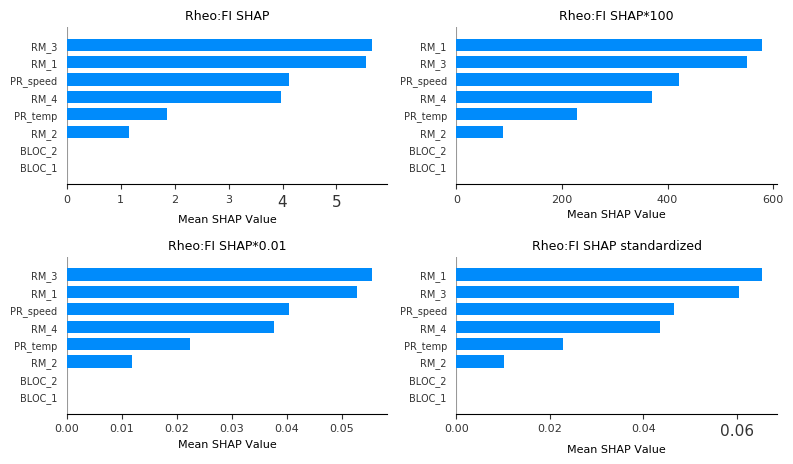

In [11]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Rheo:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values4, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Rheo:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values4_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Rheo:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values4_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Rheo:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values4_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

# Random Forest model and SHAP for Stability prediction 

In [12]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y5 = Output_Space.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y5) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y5_100 = 100*Output_Space.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y5_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y5_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y5_001 =0.01* Output_Space.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y5_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y5_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y5=df_minmax.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y5) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5_minmax = shap.TreeExplainer(model).shap_values(X)


#    Analyse Visuelle 

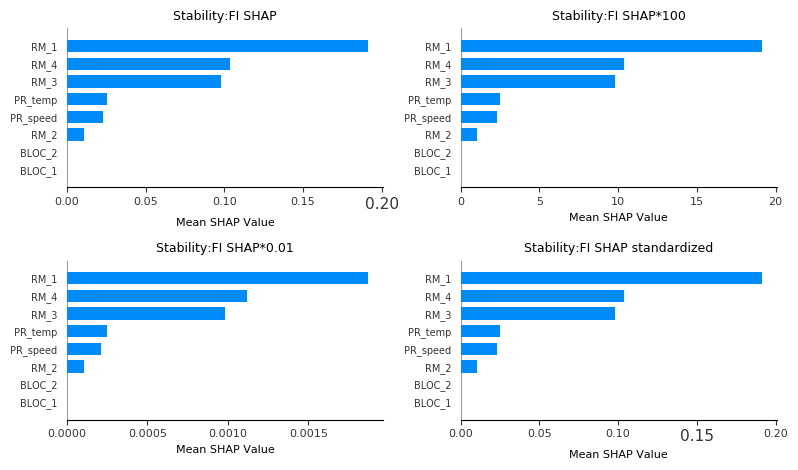

In [13]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Stability:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values5, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Stability:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values5_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Stability:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values5_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Stability:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values5_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

# Random Forest model and SHAP for Texture prediction

In [15]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y6 = Output_Space.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y6) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y6_100 = 100*Output_Space.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y6_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y6_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y6_001 =0.01* Output_Space.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y6_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y6_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y6=df_minmax.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y6) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6_minmax = shap.TreeExplainer(model).shap_values(X)

#    Analyse Visuelle 

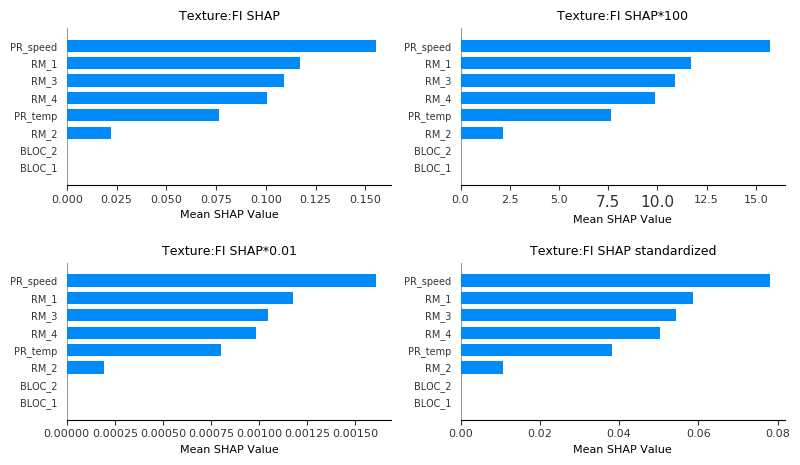

In [16]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Texture:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values6, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Texture:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values6_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Texture:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values6_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Texture:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values6_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

# Random Forest model and SHAP for Senso1 prediction

In [17]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y7 = Output_Space.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y7) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y7_100 = 100*Output_Space.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y7_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y7_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y7_001 =0.01* Output_Space.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y7_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y7_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y7=df_minmax.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y7) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7_minmax = shap.TreeExplainer(model).shap_values(X)

#    Analyse Visuelle 

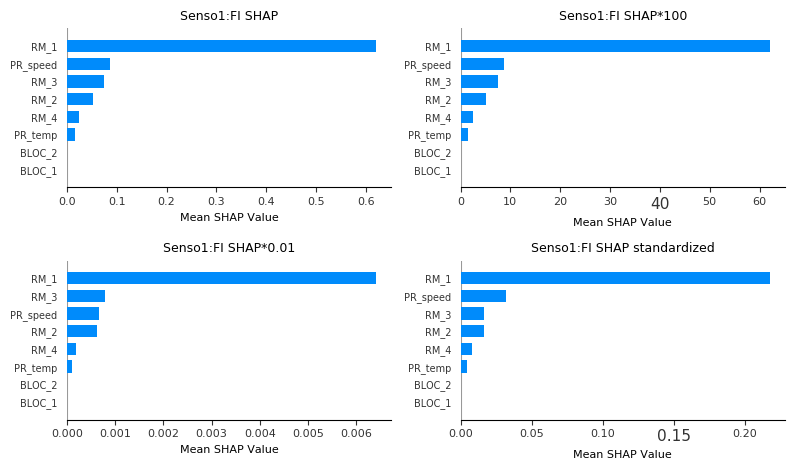

In [18]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Senso1:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values7, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Senso1:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values7_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Senso1:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values7_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Senso1:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values7_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

# Random Forest model and SHAP for Naturality prediction


In [19]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y8 = Output_Space.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y8) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y8_100 = 100*Output_Space.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y8_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y8_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y8_001 =0.01* Output_Space.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y8_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y8_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y8=df_minmax.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y8) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8_minmax = shap.TreeExplainer(model).shap_values(X)

#    Analyse Visuelle 

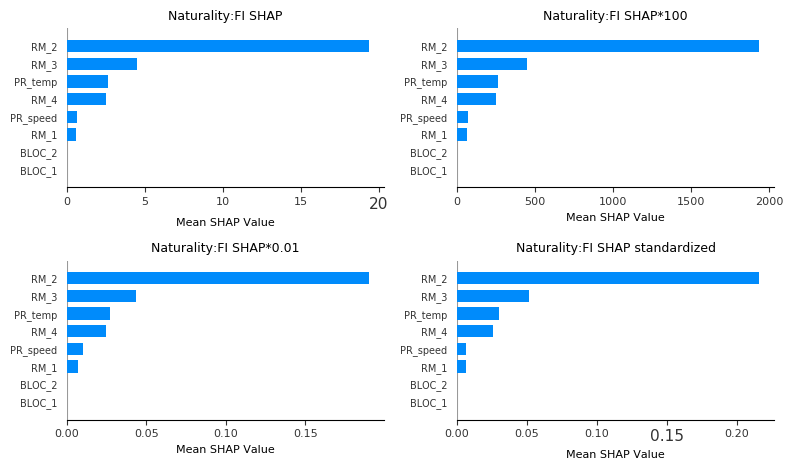

In [20]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Naturality:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values8, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Naturality:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values8_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Naturality:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values8_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Naturality:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values8_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()

# Random Forest model and SHAP for Microbio30days prediction

In [22]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y9 = Output_Space.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y9) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost multiplier par 100
Y9_100 = 100*Output_Space.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y9_100, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y9_100) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9_100 = shap.TreeExplainer(model).shap_values(X)
################################################################ Cost diviser par 100
Y9_001 =0.01* Output_Space.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y9_001, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y9_001) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9_001 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y9=df_minmax.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y9) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9_minmax = shap.TreeExplainer(model).shap_values(X)

#    Analyse Visuelle 

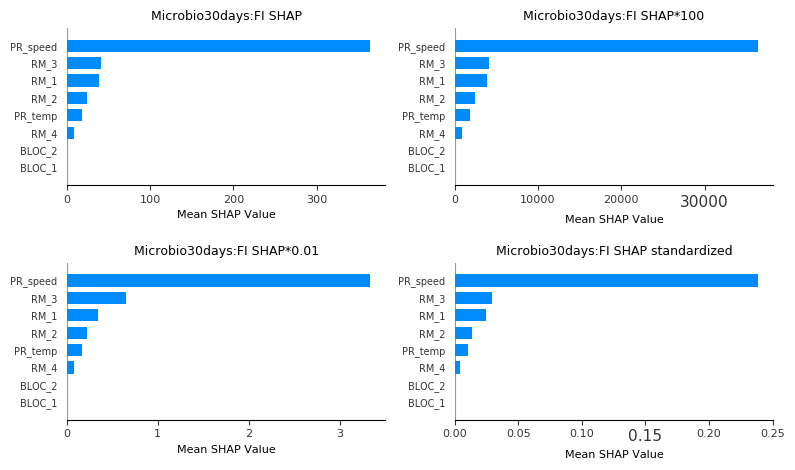

In [23]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(221) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Microbio30days:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values9, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(222)
sub2.set_title('Microbio30days:FI SHAP*100',fontsize=9)
shap.summary_plot(shap_values9_100, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(223)
sub3.set_title('Microbio30days:FI SHAP*0.01',fontsize=9)
shap.summary_plot(shap_values9_001, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(224)
sub4.set_title('Microbio30days:FI SHAP standardized',fontsize=9)
shap.summary_plot(shap_values9_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=2)
plt.tight_layout(pad=0.9,h_pad=1.4)
plt.show()